# Test Digital Clock Reader

Load the trained model and test it on a digital clock image.

In [1]:
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models

In [2]:
# Setup
BASE_DIR = Path(".")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("Using device:", DEVICE)

Using device: cpu


In [3]:
# Model definition
class DigitalTimeReader(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.hour_head = nn.Linear(num_features, 24)
        self.minute_head = nn.Linear(num_features, 60)
        self.second_head = nn.Linear(num_features, 60)

    def forward(self, x):
        features = self.backbone(x)

        hour_pred = self.hour_head(features)
        minute_pred = self.minute_head(features)
        second_pred = self.second_head(features)

        return hour_pred, minute_pred, second_pred

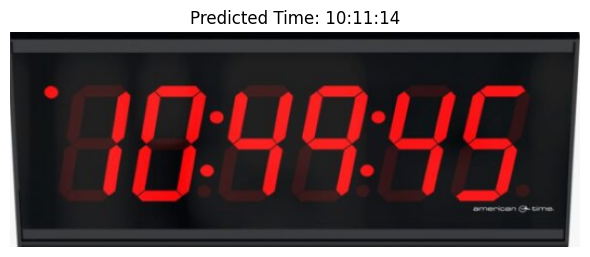

✓ Successfully predicted time: 10:11:14


In [5]:
# Load the best model from storage
model_path = BASE_DIR / "models" / "digital_time_reader.pth"
image_path = Path("test_clock.png")  # Replace this with your image path

try:
    # Load model
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found at: {model_path}")
    
    model = DigitalTimeReader().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    
    # Load image
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found at: {image_path}")
    
    image = Image.open(image_path).convert("RGB")
    
    # Preprocess and predict
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        pred_hour, pred_minute, pred_second = model(input_tensor)
    
    pred_hour = torch.argmax(pred_hour, dim=1).item()
    pred_minute = torch.argmax(pred_minute, dim=1).item()
    pred_second = torch.argmax(pred_second, dim=1).item()
    
    # Display results
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted Time: {pred_hour:02d}:{pred_minute:02d}:{pred_second:02d}")
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Successfully predicted time: {pred_hour:02d}:{pred_minute:02d}:{pred_second:02d}")
    
except Exception as e:
    print(f"✗ Error: {e}")